In [1]:
!pip install SimpleITK tf-keras-vis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.7 MB/s eta 0:00:00


In [2]:
# CELL 1: Imports and paths                                                                                  2

import os
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import random
from collections import Counter

# Paths

PREPROCESSED_ROOT = "/kaggle/input/datasets/prakhar0verma0333/mri-brisc-dataset/brisc2025_preprocessed"

TRAIN_IMGS_DIR  = f"{PREPROCESSED_ROOT}/train/images"
TRAIN_MASKS_DIR = f"{PREPROCESSED_ROOT}/train/masks"
TEST_IMGS_DIR   = f"{PREPROCESSED_ROOT}/test/images"
TEST_MASKS_DIR  = f"{PREPROCESSED_ROOT}/test/masks"

# Model constants
IMAGE_SIZE  = 256
NUM_CLASSES = 4
BATCH_SIZE  = 16

# UPDATED: both 'nt' and 'no' map to class 3 (No Tumor)
TUMOR_CODE_MAP = {"gl": 0, "me": 1, "pi": 2, "nt": 3, "no": 3}
CLASS_NAMES    = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

print("✅ Imports and paths ready")
print(f"   TensorFlow version: {tf.__version__}")

2026-02-21 20:56:41.180204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771707401.369361      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771707401.423951      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771707401.859616      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771707401.859661      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771707401.859664      24 computation_placer.cc:177] computation placer alr

✅ Imports and paths ready
   TensorFlow version: 2.19.0


In [3]:
# Quick path check                                                                                  3
print("Checking paths:")
for name, path in [
    ("Train images", TRAIN_IMGS_DIR),
    ("Train masks",  TRAIN_MASKS_DIR),
    ("Test images",  TEST_IMGS_DIR),
    ("Test masks",   TEST_MASKS_DIR)
]:
    exists = os.path.exists(path)
    count  = len(list(Path(path).glob("*.npy"))) if exists else 0
    print(f"  {'✅' if exists else '❌'} {name}: {count} files")

Checking paths:
  ✅ Train images: 5000 files
  ✅ Train masks: 5000 files
  ✅ Test images: 1000 files
  ✅ Test masks: 1000 files


In [4]:
# CELL 2: Parse filenames and build file lists                                                                                  4

def get_label_from_filename(filename: str) -> int:
    """
    Extract integer class label from BRISC filename.
    Example: brisc2025_train_00001_gl_ax_t1.npy → 0 (Glioma)
    """
    stem  = Path(filename).stem
    parts = stem.split("_")
    tumor_code = parts[3]
    return TUMOR_CODE_MAP[tumor_code]


def build_file_lists(img_dir: str, mask_dir: str):
    """
    Build three parallel lists:
      image_paths, mask_paths, labels
    """
    img_paths = sorted(Path(img_dir).glob("*.npy"))

    image_paths, mask_paths, labels = [], [], []
    skipped = 0

    for img_path in img_paths:
        mask_path = Path(mask_dir) / img_path.name

        if not mask_path.exists():
            skipped += 1
            continue

        image_paths.append(str(img_path))
        mask_paths.append(str(mask_path))
        labels.append(get_label_from_filename(img_path.name))

    print(f"  Found   : {len(image_paths)} valid pairs")
    if skipped:
        print(f"  Skipped : {skipped} (no matching mask)")

    dist = Counter(labels)
    for idx, name in enumerate(CLASS_NAMES):
        print(f"    {name:<15}: {dist[idx]} samples")

    return image_paths, mask_paths, labels


print("TRAIN:")
train_images, train_masks, train_labels = build_file_lists(
    TRAIN_IMGS_DIR, TRAIN_MASKS_DIR
)
print("\nTEST:")
test_images, test_masks, test_labels = build_file_lists(
    TEST_IMGS_DIR, TEST_MASKS_DIR
)

TRAIN:
  Found   : 5000 valid pairs
    Glioma         : 1147 samples
    Meningioma     : 1329 samples
    Pituitary      : 1457 samples
    No Tumor       : 1067 samples

TEST:
  Found   : 1000 valid pairs
    Glioma         : 254 samples
    Meningioma     : 306 samples
    Pituitary      : 300 samples
    No Tumor       : 140 samples


In [5]:
# CELL 3: Compute class weights to handle class imbalance                                                                                  5

def compute_class_weights(labels: list) -> dict:
    """Compute balanced class weights."""
    total   = len(labels)
    counter = Counter(labels)
    weights = {}

    print(f"  Total samples : {total}")
    print(f"  Label counts  : {dict(sorted(counter.items()))}")
    print()

    for class_idx in range(NUM_CLASSES):
        count = counter.get(class_idx, 0)
        if count == 0:
            print(f"  ⚠️  Class {class_idx} ({CLASS_NAMES[class_idx]}) "
                  f"has 0 samples")
            weights[class_idx] = 1.0
        else:
            weights[class_idx] = round(total / (NUM_CLASSES * count), 4)

    return weights


CLASS_WEIGHTS = compute_class_weights(train_labels)

print("Class weights for training:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name:<15}: {CLASS_WEIGHTS[idx]:.4f}")

print()
print("Weights close to 1.0 = balanced")
print("Weights > 1.0 = underrepresented class")

  Total samples : 5000
  Label counts  : {0: 1147, 1: 1329, 2: 1457, 3: 1067}

Class weights for training:
  Glioma         : 1.0898
  Meningioma     : 0.9406
  Pituitary      : 0.8579
  No Tumor       : 1.1715

Weights close to 1.0 = balanced
Weights > 1.0 = underrepresented class


In [6]:
# CELL 4: Function to load one image-mask-label triplet                                                                                  6

def load_sample(img_path, mask_path, label):
    """
    Load one preprocessed sample from .npy files.
    Returns: image (256,256,3), mask (256,256,1), one_hot_label (4,)
    """
    img_path  = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    image   = np.load(img_path).astype(np.float32)   # (256,256,3)
    mask    = np.load(mask_path).astype(np.float32)   # (256,256,1)
    one_hot = tf.one_hot(label, depth=NUM_CLASSES)

    return image, mask, one_hot


def load_wrapper(img_path, mask_path, label):
    """Wrapper that calls load_sample inside tf.py_function."""
    image, mask, one_hot = tf.py_function(
        func=load_sample,
        inp=[img_path, mask_path, label],
        Tout=[tf.float32, tf.float32, tf.float32]
    )

    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    mask.set_shape([IMAGE_SIZE, IMAGE_SIZE, 1])
    one_hot.set_shape([NUM_CLASSES])

    return image, mask, one_hot

print("✅ Load functions defined")

✅ Load functions defined


In [7]:
# CELL 5: Augmentation — applied to image AND mask consistently                                                                                  7

def augment_sample(image, mask, label):
    """
    Random augmentations applied identically to image and mask.
    Only called during training.
    """
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)

    # Brightness — image only
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.clip_by_value(image, 0.0, 1.0)

    # Contrast — image only
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask, label


def format_output(image, mask, label):
    """
    Format output as dict to match multi-output model.
    Keys must match output layer names in the model.
    """
    return image, {
        "seg_output": mask,
        "cls_output": label
    }

print("✅ Augmentation functions defined")

✅ Augmentation functions defined


In [8]:
# CELL 6: Build the complete tf.data pipeline                                                                                  8

def build_dataset(img_paths, mask_paths, labels,
                  batch_size=BATCH_SIZE,
                  shuffle=False,
                  augment=False) -> tf.data.Dataset:
    """
    Build a tf.data.Dataset from file path lists.
    Returns batched dataset yielding:
      (image, {'seg_output': mask, 'cls_output': label})
    """

    # Step 1: Create dataset from lists
    ds = tf.data.Dataset.from_tensor_slices((
        img_paths,
        mask_paths,
        labels
    ))

    # Step 2: Shuffle (train only)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(img_paths),
            seed=42,
            reshuffle_each_iteration=True
        )

    # Step 3: Load .npy files in parallel
    ds = ds.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 4: Augment (train only)
    if augment:
        ds = ds.map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 5: Format output as dict
    ds = ds.map(format_output, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 6: Batch
    ds = ds.batch(batch_size)

    # Step 7: Prefetch — GPU trains on batch N while CPU loads batch N+1
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# Build datasets
print("Building datasets...")

train_dataset = build_dataset(
    train_images, train_masks, train_labels,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True
)

test_dataset = build_dataset(
    test_images, test_masks, test_labels,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

print(f"\n✅ Train dataset : {len(train_images)} samples → "
      f"{len(train_images)//BATCH_SIZE} batches per epoch")
print(f"✅ Test dataset  : {len(test_images)} samples → "
      f"{len(test_images)//BATCH_SIZE} batches per epoch")

Building datasets...


I0000 00:00:1771707434.939075      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



✅ Train dataset : 5000 samples → 312 batches per epoch
✅ Test dataset  : 1000 samples → 62 batches per epoch


In [9]:
# CELL 2: Swin Transformer building blocks                                                                                  9
#
# WHY Swin at the bottleneck:
# After EfficientNet compresses the image down to an 8x8 feature map,
# we need the model to understand GLOBAL context — where is the tumor
# relative to the whole brain structure? CNNs can only see local patches.
# Swin Transformer's self-attention looks at ALL positions simultaneously,
# giving it that global understanding.
from tensorflow.keras import layers, Model

class WindowAttention(layers.Layer):
    """
    Window-based Multi-Head Self-Attention.

    WHY windows: Full self-attention on an 8x8 map with 256 channels
    would be expensive. We divide into 4x4 windows and run attention
    within each window. Still captures meaningful spatial relationships
    at this compressed scale.
    """
    def __init__(self, dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5

        self.qkv    = layers.Dense(dim * 3, use_bias=True)
        self.proj   = layers.Dense(dim)

    def call(self, x, training=False):
        B  = tf.shape(x)[0]
        N  = tf.shape(x)[1]
        C  = self.dim

        # Project to queries, keys, values
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)

        # Apply attention to values
        x = tf.matmul(attn, v)
        x = tf.transpose(x, [0, 2, 1, 3])
        x = tf.reshape(x, [B, N, C])
        x = self.proj(x)
        return x


class SwinBlock(layers.Layer):
    """
    One complete Swin Transformer block.

    Structure:
      Input → LayerNorm → WindowAttention → Add (residual)
            → LayerNorm → MLP → Add (residual)

    WHY Pre-LayerNorm (norm before attention):
      More stable gradients during training than post-norm.

    WHY residual connections:
      Allows gradients to flow directly back through the network
      without vanishing. Essential for deep networks.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4.0,
                 dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = WindowAttention(dim, num_heads)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_hidden, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        H = x.shape[1]
        W = x.shape[2]
        C = self.dim

        shortcut = x

        # Flatten spatial dims for attention: (B,H,W,C) → (B,H*W,C)
        x = self.norm1(x)
        x_flat = tf.reshape(x, [B, H * W, C])

        # Self-attention across all spatial positions
        attn_out = self.attn(x_flat, training=training)

        # Reshape back: (B,H*W,C) → (B,H,W,C)
        attn_out = tf.reshape(attn_out, [B, H, W, C])

        # First residual
        x = shortcut + attn_out

        # MLP with second residual
        x = x + self.mlp(self.norm2(x), training=training)

        return x

print("✅ Swin Transformer components defined")

✅ Swin Transformer components defined


In [10]:
# CELL 3: U-Net style decoder block                                                                                  10
#
# WHY skip connections:
# EfficientNet progressively compresses spatial information.
# A 256x256 image becomes 8x8 at the bottleneck — most spatial
# detail is lost. Skip connections bring back fine-grained
# spatial information from earlier encoder layers directly into
# the decoder. Without them, your segmentation mask boundaries
# will be blurry and inaccurate.
#
# Think of it like this:
# Bottleneck knows WHAT the tumor is (high-level semantic)
# Skip connections know WHERE exactly it is (fine spatial detail)
# Together they produce sharp, accurate masks.

def decoder_block(x, skip, filters, name):
    """
    One decoder step:
      Upsample 2x → Concatenate skip → Conv → BN → ReLU → Conv → BN → ReLU

    Args:
        x      : input feature map from previous decoder step
        skip   : skip connection from encoder (can be None)
        filters: number of conv filters
        name   : prefix for layer naming
    """
    # Upsample spatial dims by 2x
    x = layers.UpSampling2D(
        size=(2, 2),
        interpolation="bilinear",
        name=f"{name}_up"
    )(x)

    # Concatenate skip connection if available
    if skip is not None:
        # Project skip to same channel count if needed
        if skip.shape[-1] != filters:
            skip = layers.Conv2D(
                filters, 1, padding="same",
                name=f"{name}_skip_proj"
            )(skip)
        x = layers.Concatenate(name=f"{name}_concat")([x, skip])

    # Two conv blocks — standard U-Net decoder pattern
    x = layers.Conv2D(filters, 3, padding="same",
                      use_bias=False, name=f"{name}_c1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_r1")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                      use_bias=False, name=f"{name}_c2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_r2")(x)

    return x

print("✅ Decoder block defined")

✅ Decoder block defined


In [11]:
# CELL 4: Build 90%+ Model                                                                                  11
# Combines: Multi-Scale Classification + SE Attention + Stronger Head

from tensorflow.keras import layers, Model

# ── SQUEEZE AND EXCITATION BLOCK ──────────────────────────────────
# WHY SE Block:
# Standard conv treats all channels equally.
# SE block learns WHICH channels are most important for the task
# by squeezing spatial info into channel descriptors and then
# re-weighting each channel accordingly.
# Adds ~3-5% accuracy with almost no extra parameters.

def se_block(x, ratio=16, name="se"):
    """
    Squeeze-and-Excitation attention block.
    Learns channel importance weights.
    """
    channels = x.shape[-1]

    # Squeeze — global average pool → (B, C)
    se = layers.GlobalAveragePooling2D(name=f"{name}_squeeze")(x)

    # Excitation — two FC layers
    se = layers.Dense(
        channels // ratio,
        activation="relu",
        use_bias=False,
        name=f"{name}_fc1"
    )(se)
    se = layers.Dense(
        channels,
        activation="sigmoid",
        use_bias=False,
        name=f"{name}_fc2"
    )(se)

    # Reshape for multiplication: (B,C) → (B,1,1,C)
    se = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(se)

    # Scale input channels by learned weights
    x = layers.Multiply(name=f"{name}_scale")([x, se])
    return x


# ── MULTI-SCALE FEATURE FUSION ────────────────────────────────────
# WHY multi-scale:
# Different tumor types have different size characteristics.
# Gliomas are large — captured at low-resolution deep features.
# Meningiomas can be small — captured at high-resolution shallow features.
# Fusing all scales gives classification access to ALL this information
# instead of just the bottleneck.

def multiscale_fusion(skip_features, bottleneck, target_dim=256, name="msf"):
    """
    Fuse features from multiple encoder scales for classification.
    All scale features are pooled and concatenated.
    """
    fused = []

    # Process each skip connection
    for i, skip in enumerate(skip_features):
        # Project to common dimension
        s = layers.Conv2D(
            64, 1, padding="same",
            use_bias=False,
            name=f"{name}_proj_{i}"
        )(skip)
        s = layers.BatchNormalization(name=f"{name}_bn_{i}")(s)
        s = layers.Activation("relu", name=f"{name}_act_{i}")(s)
        # Pool to single vector
        s = layers.GlobalAveragePooling2D(name=f"{name}_gap_{i}")(s)
        fused.append(s)

    # Add bottleneck features
    b = layers.GlobalAveragePooling2D(name=f"{name}_gap_btn")(bottleneck)
    fused.append(b)

    # Concatenate all scales
    x = layers.Concatenate(name=f"{name}_concat")(fused)

    # Project to target dimension
    x = layers.Dense(target_dim, name=f"{name}_dense")(x)
    x = layers.BatchNormalization(name=f"{name}_final_bn")(x)
    x = layers.Activation("relu", name=f"{name}_final_act")(x)

    return x


# ── MAIN MODEL ────────────────────────────────────────────────────
def build_model_v3(
    input_shape = (256, 256, 3),
    num_classes = NUM_CLASSES,
    swin_dim    = 256,
    swin_heads  = 8,
):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ── ENCODER ───────────────────────────────────────────────────
    base = tf.keras.applications.EfficientNetB4(
        include_top  = False,
        weights      = "imagenet",
        input_tensor = inputs
    )

    skip_layer_names = [
        "block2a_expand_activation",   # 64x64
        "block3a_expand_activation",   # 32x32
        "block4a_expand_activation",   # 16x16
        "block6a_expand_activation",   # 8x8
    ]

    skips       = [base.get_layer(n).output for n in skip_layer_names]
    encoder_out = base.output   # 8x8 x 1792

    # ── BOTTLENECK PROJECTION ─────────────────────────────────────
    x = layers.Conv2D(
        swin_dim, 1, padding="same",
        use_bias=False, name="bottleneck_proj"
    )(encoder_out)
    x = layers.BatchNormalization(name="bottleneck_bn")(x)
    x = layers.Activation("relu", name="bottleneck_relu")(x)

    # ── SWIN TRANSFORMER ──────────────────────────────────────────
    x = SwinBlock(dim=swin_dim, num_heads=swin_heads, name="swin_1")(x)
    x = SwinBlock(dim=swin_dim, num_heads=swin_heads, name="swin_2")(x)

    # ── SE ATTENTION ──────────────────────────────────────────────
    # Applied after Swin to re-weight channels based on tumor relevance
    x = se_block(x, ratio=16, name="se_bottleneck")
    swin_out = x

    # ── MULTI-SCALE CLASSIFICATION HEAD ───────────────────────────
    # Uses features from ALL encoder scales + bottleneck
    # This is the key difference from v1 and v2
    ms_features = multiscale_fusion(
        skip_features=skips,
        bottleneck=swin_out,
        target_dim=256,
        name="msf"
    )

    # Strong classification head on top of multi-scale features
    cls = layers.Dense(512, name="cls_d1")(ms_features)
    cls = layers.BatchNormalization(name="cls_bn1")(cls)
    cls = layers.Activation("relu", name="cls_r1")(cls)
    cls = layers.Dropout(0.4, name="cls_drop1")(cls)

    cls = layers.Dense(256, name="cls_d2")(cls)
    cls = layers.BatchNormalization(name="cls_bn2")(cls)
    cls = layers.Activation("relu", name="cls_r2")(cls)
    cls = layers.Dropout(0.3, name="cls_drop2")(cls)

    cls = layers.Dense(128, name="cls_d3")(cls)
    cls = layers.BatchNormalization(name="cls_bn3")(cls)
    cls = layers.Activation("relu", name="cls_r3")(cls)
    cls = layers.Dropout(0.2, name="cls_drop3")(cls)

    cls_output = layers.Dense(
        num_classes, activation="softmax", name="cls_output"
    )(cls)

    # ── SEGMENTATION DECODER (unchanged) ─────────────────────────
    d = decoder_block(swin_out, skips[3], filters=256, name="dec4")
    d = decoder_block(d,        skips[2], filters=128, name="dec3")
    d = decoder_block(d,        skips[1], filters=64,  name="dec2")
    d = decoder_block(d,        skips[0], filters=32,  name="dec1")
    d = decoder_block(d,        None,     filters=16,  name="dec0")

    seg_output = layers.Conv2D(
        1, 1, activation="sigmoid", name="seg_output"
    )(d)

    # ── BUILD ─────────────────────────────────────────────────────
    model = Model(
        inputs  = inputs,
        outputs = {"seg_output": seg_output, "cls_output": cls_output},
        name    = "SwinEfficientNet_v3"
    )

    return model, base

print("✅ Model v3 builder defined")

✅ Model v3 builder defined


In [12]:
# CELL 5: Build v3 model                                                                                                12

print("Building model v3...")
model, base_model = build_model_v3()
print(f"✅ Model v3 | Parameters: {model.count_params():,}")

print("\nOutput shapes:")
for name, output in model.output.items():
    print(f"   {name} : {output.shape}")

Building model v3...
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model v3 | Parameters: 23,119,700

Output shapes:
   seg_output : (None, 256, 256, 1)
   cls_output : (None, 4)


In [13]:
# CELL 6: Custom loss functions and metrics                                                                                  13

import tensorflow as tf

# ── SEGMENTATION LOSS ─────────────────────────────────────────────
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss = 1 - Dice Score

    WHY: Directly optimizes the metric we report.
    Handles class imbalance naturally — a small tumor region
    covering 5% of pixels gets equal importance to a large one.
    Standard cross entropy would ignore small tumors.
    """
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
    return 1.0 - dice


def bce_dice_loss(y_true, y_pred):
    """
    Combined BCE + Dice Loss

    WHY combine:
    BCE: provides stable pixel-level gradient signal from the start
    Dice: provides region-level signal that optimizes overlap

    BCE alone → stable but ignores class imbalance
    Dice alone → can be unstable early in training
    Together  → best of both
    """
    bce  = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice


# ── CLASSIFICATION LOSS ───────────────────────────────────────────
def label_smoothing_loss(y_true, y_pred):
    """
    Categorical Cross Entropy with Label Smoothing (0.1)

    WHY label smoothing:
    Hard labels (exactly 0 or 1) push the model to be overconfident.
    Smoothing replaces 1.0 → 0.9 and 0.0 → 0.033.
    Results in better calibrated confidence scores — important
    for clinical use where you want meaningful probability outputs.
    """
    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    )
    return loss_fn(y_true, y_pred)


# ── CUSTOM DICE METRIC ────────────────────────────────────────────
class DiceCoefficient(tf.keras.metrics.Metric):
    """
    Tracks Dice Score during training/validation.
    Reported after every epoch so you can monitor segmentation quality.
    """
    def __init__(self, name="dice", **kwargs):
        super().__init__(name=name, **kwargs)
        self.dice_sum = self.add_weight(name="sum",   initializer="zeros")
        self.count    = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Threshold at 0.5 to get binary prediction
        y_pred_bin   = tf.cast(y_pred > 0.5, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        union        = (tf.reduce_sum(y_true, axis=[1,2,3]) +
                        tf.reduce_sum(y_pred_bin, axis=[1,2,3]))
        dice         = (2.0 * intersection + 1e-6) / (union + 1e-6)
        self.dice_sum.assign_add(tf.reduce_sum(dice))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.dice_sum / self.count

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

print("✅ Loss functions and metrics defined")

✅ Loss functions and metrics defined


In [14]:
# CELL 7: Two-stage loss strategy                                                                              14
#
# WHY two different compile functions:
# Phase A (seg-focused): seg=1.0, cls=0.3
#   Encoder learns strong spatial features first
#   Segmentation decoder reaches good performance
#   Classification benefits from strong spatial encoder
#
# Phase B (cls-focused): seg=0.7, cls=1.0
#   Now push classification hard
#   Segmentation decoder is frozen so it can't degrade
#   Classification head gets full gradient signal

def compile_seg_focused(model, lr):
    """Phase A — segmentation focused"""
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=1e-4
        ),
        loss={
            "seg_output": bce_dice_loss,
            "cls_output": label_smoothing_loss
        },
        loss_weights={
            "seg_output": 1.0,
            "cls_output": 0.3   # cls gets less weight first
        },
        metrics={
            "seg_output": [DiceCoefficient()],
            "cls_output": [
                tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
                tf.keras.metrics.AUC(name="auc", multi_label=False)
            ]
        }
    )
    print(f"✅ Seg-focused compile | LR: {lr}")


def compile_cls_focused(model, lr):
    """Phase B — classification focused"""
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=1e-4
        ),
        loss={
            "seg_output": bce_dice_loss,
            "cls_output": label_smoothing_loss
        },
        loss_weights={
            "seg_output": 0.7,
            "cls_output": 1.0   # cls gets full weight
        },
        metrics={
            "seg_output": [DiceCoefficient()],
            "cls_output": [
                tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
                tf.keras.metrics.AUC(name="auc", multi_label=False)
            ]
        }
    )
    print(f"✅ Cls-focused compile | LR: {lr}")


# Start with seg-focused for initial compile
compile_seg_focused(model, lr=1e-3)

✅ Seg-focused compile | LR: 0.001


In [15]:
# Final confirmation check before training                                                                                  15
print("Pre-training checklist:")
print(f"  Train samples : {len(train_images)}")
print(f"  Test samples  : {len(test_images)}")
print(f"  Model params  : {model.count_params():,}")
print(f"  GPU available : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Steps/epoch   : {len(train_images)//BATCH_SIZE}")

Pre-training checklist:
  Train samples : 5000
  Test samples  : 1000
  Model params  : 23,119,700
  GPU available : True
  Batch size    : 16
  Steps/epoch   : 312


In [16]:
####### phase 5                                                                                  16

In [17]:
# CELL 1: Create output directories for saving checkpoints and logs                                                             17

import os

OUTPUT_DIR      = "/kaggle/working/outputs"
CHECKPOINT_DIR  = f"{OUTPUT_DIR}/checkpoints"
LOG_DIR         = f"{OUTPUT_DIR}/logs"
PLOT_DIR        = f"{OUTPUT_DIR}/plots"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, LOG_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Output directories created")
print(f"   Checkpoints : {CHECKPOINT_DIR}")
print(f"   Logs        : {LOG_DIR}")
print(f"   Plots       : {PLOT_DIR}")

✅ Output directories created
   Checkpoints : /kaggle/working/outputs/checkpoints
   Logs        : /kaggle/working/outputs/logs
   Plots       : /kaggle/working/outputs/plots


In [18]:
# CELL 2: Training callbacks                                                                                  18
#
# WHY each callback:
# ModelCheckpoint : saves the best model automatically so even if 
#                   training crashes you don't lose your best weights
# ReduceLROnPlateau: when loss stops improving, reduce learning rate
#                   by half — helps escape plateaus
# EarlyStopping   : stops training if no improvement for N epochs
#                   prevents wasting GPU time on a stuck model
# CSVLogger       : saves loss/metric history to a CSV file
#                   so you can analyze training curves later

def get_callbacks(stage: int):
    return [
        # Save best model based on validation Dice score
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/stage{stage}_best.weights.h5",
            monitor="val_seg_output_dice",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        # Reduce LR when validation loss plateaus
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
        # Stop early if no improvement
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        # Save training history to CSV
        tf.keras.callbacks.CSVLogger(
            f"{LOG_DIR}/stage{stage}_history.csv",
            append=False
        )
    ]

print("✅ Callbacks defined")

✅ Callbacks defined


In [19]:
# CELL 3: Stage 1 FIXED — more stable training

print("=" * 55)
print("STAGE 1 FIXED: Warmup with frozen encoder")
print("=" * 55)

base_model.trainable = False

# Fix 1: Higher cls loss weight (0.5 instead of 0.3)
# so classification gets more stable gradient signal
# Fix 2: Lower initial LR (3e-4 instead of 1e-3)
# so classification head doesn't oscillate

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss={
        "seg_output": bce_dice_loss,
        "cls_output": label_smoothing_loss
    },
    loss_weights={
        "seg_output": 1.0,
        "cls_output": 0.5  # increased from 0.3
    },
    metrics={
        "seg_output": [DiceCoefficient()],
        "cls_output": [
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=False)
        ]
    }
)

print(f"  Trainable : {len(model.trainable_weights)}")
print(f"  Frozen    : {len(model.non_trainable_weights)}\n")

history1 = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=25,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/stage1_best.weights.h5",
            monitor="val_seg_output_dice",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,    # increased from 4 — more patient
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=12,   # increased from 8 — more patient
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            f"{LOG_DIR}/stage1_history.csv"
        )
    ],
    verbose=1
)

print("✅ Stage 1 complete")

STAGE 1 FIXED: Warmup with frozen encoder
  Trainable : 99
  Frozen    : 649

Epoch 1/25


I0000 00:00:1771707473.955958      71 service.cc:152] XLA service 0x7b3bc8003250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771707473.956009      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771707480.962007      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771707524.222152      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - cls_output_accuracy: 0.3217 - cls_output_auc: 0.5808 - cls_output_loss: 1.5999 - loss: 2.2497 - seg_output_dice: 0.0750 - seg_output_loss: 1.4498
Epoch 1: val_seg_output_dice improved from -inf to 0.07906, saving model to /kaggle/working/outputs/checkpoints/stage1_best.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 250s 527ms/step - cls_output_accuracy: 0.3218 - cls_output_auc: 0.5809 - cls_output_loss: 1.5995 - loss: 2.2491 - seg_output_dice: 0.0753 - seg_output_loss: 1.4494 - val_cls_output_accuracy: 0.1730 - val_cls_output_auc: 0.4698 - val_cls_output_loss: 1.6680 - val_loss: 2.0801 - val_seg_output_dice: 0.0791 - val_seg_output_loss: 1.2473 - learning_rate: 3.0000e-04
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - cls_output_accuracy: 0.4484 - cls_output_auc: 0.7108 - cls_output_loss: 1.3233 - loss: 1.8119 - seg_output_dice: 0.3783 - seg_output_loss: 1.1502
Epoch 2: val_seg_output_dice improved from 0.07906 to 0.20452, saving model to 

In [20]:
# CELL 4: Stage 2 + Stage 3 — Two-phase fine-tuning

# ── STAGE 2: Encoder unfrozen, balanced training ──────────────────
print("=" * 55)
print("STAGE 2: Encoder unfrozen, balanced (35 epochs)")
print("=" * 55)

base_model.trainable = True
for layer in base_model.layers[:50]:
    layer.trainable = False

# Changed: balanced loss weights + val_loss monitoring
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss={
        "seg_output": bce_dice_loss,
        "cls_output": label_smoothing_loss
    },
    loss_weights={
        "seg_output": 1.0,
        "cls_output": 0.8   # stronger cls signal than Stage 1
    },
    metrics={
        "seg_output": [DiceCoefficient()],
        "cls_output": [
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=False)
        ]
    }
)

print(f"\n  Trainable : {len(model.trainable_weights)}\n")

history2 = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=35,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/stage2_best.weights.h5",
            monitor="val_loss",        # changed from val_seg_output_dice
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,                # more patient
            min_lr=1e-8,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,               # very patient
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            f"{LOG_DIR}/stage2_history.csv"
        )
    ],
    verbose=1
)

print("✅ Stage 2 complete")

# Load best Stage 2 weights before Stage 3
model.load_weights(f"{CHECKPOINT_DIR}/stage2_best.weights.h5")
print("✅ Best Stage 2 weights loaded for Stage 3")

# ── STAGE 3: Freeze seg decoder, cls focused ──────────────────────
print("\n" + "=" * 55)
print("STAGE 3: Seg decoder frozen, cls focused (25 epochs)")
print("=" * 55)

# Freeze segmentation decoder layers
seg_decoder_prefixes = ["dec0", "dec1", "dec2", "dec3", "dec4", "seg_output"]
frozen_count = 0
for layer in model.layers:
    for prefix in seg_decoder_prefixes:
        if layer.name.startswith(prefix):
            layer.trainable = False
            frozen_count += 1

# Freeze encoder too — only cls head + fusion block trains
base_model.trainable = False

print(f"\n  Frozen seg decoder layers : {frozen_count}")
print(f"  Trainable weights         : {len(model.trainable_weights)}")
print(f"  (Only cls head + fusion block training now)\n")

# Higher LR for cls head since it's the only thing updating
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-5,
        weight_decay=1e-4
    ),
    loss={
        "seg_output": bce_dice_loss,
        "cls_output": label_smoothing_loss
    },
    loss_weights={
        "seg_output": 0.3,   # seg decoder frozen so this barely matters
        "cls_output": 1.0    # full weight on classification
    },
    metrics={
        "seg_output": [DiceCoefficient()],
        "cls_output": [
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=False)
        ]
    }
)

history3 = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=25,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/stage3_best.weights.h5",
            monitor="val_cls_output_accuracy",  # now track accuracy
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_cls_output_accuracy",
            factor=0.5,
            patience=5,
            min_lr=1e-8,
            mode="max",
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_cls_output_accuracy",
            patience=10,
            restore_best_weights=True,
            mode="max",
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            f"{LOG_DIR}/stage3_history.csv"
        )
    ],
    verbose=1
)

print("\n✅ Stage 3 complete")
print("   Classification accuracy peak reached here")

STAGE 2: Encoder unfrozen, balanced (35 epochs)

  Trainable : 473

Epoch 1/35


2026-02-21 21:29:46.438005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:29:46.622935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:29:46.958034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:29:47.142614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:29:47.539996: E external/local_xla/xla/stream_

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - cls_output_accuracy: 0.4486 - cls_output_auc: 0.7166 - cls_output_loss: 1.3914 - loss: 2.1202 - seg_output_dice: 0.1146 - seg_output_loss: 1.0070

2026-02-21 21:32:32.513453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:32:32.698114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:32:33.028221: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:32:33.227847: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-21 21:32:33.742395: E external/local_xla/xla/stream_

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - cls_output_accuracy: 0.4488 - cls_output_auc: 0.7168 - cls_output_loss: 1.3910 - loss: 2.1196 - seg_output_dice: 0.1147 - seg_output_loss: 1.0068
Epoch 1: val_loss improved from inf to 1.88567, saving model to /kaggle/working/outputs/checkpoints/stage2_best.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 360s 638ms/step - cls_output_accuracy: 0.4490 - cls_output_auc: 0.7170 - cls_output_loss: 1.3905 - loss: 2.1191 - seg_output_dice: 0.1149 - seg_output_loss: 1.0066 - val_cls_output_accuracy: 0.5740 - val_cls_output_auc: 0.8160 - val_cls_output_loss: 1.1641 - val_loss: 1.8857 - val_seg_output_dice: 0.1958 - val_seg_output_loss: 0.9506 - learning_rate: 1.0000e-05
Epoch 2/35
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - cls_output_accuracy: 0.6226 - cls_output_auc: 0.8561 - cls_output_loss: 1.0266 - loss: 1.6576 - seg_output_dice: 0.2350 - seg_output_loss: 0.8364
Epoch 2: val_loss improved from 1.88567 to 1.50616, saving model to /kaggle/working/outputs

In [21]:
# Define paths explicitly and save
import os

OUTPUT_DIR     = "/kaggle/working/outputs"
CHECKPOINT_DIR = f"{OUTPUT_DIR}/checkpoints"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save best Stage 3 weights first (most important)
model.load_weights(f"{CHECKPOINT_DIR}/stage3_best.weights.h5")
print("✅ Best Stage 3 weights loaded")

# Save full model
model.save(f"{OUTPUT_DIR}/final_model_v3.keras")
print(f"✅ Full model saved: {OUTPUT_DIR}/final_model_v3.keras")

# Save weights backup
model.save_weights(f"{OUTPUT_DIR}/final_weights_v3.weights.h5")
print(f"✅ Weights saved  : {OUTPUT_DIR}/final_weights_v3.weights.h5")

print("\n⚠️  NOW: Click Save Version → Save & Run All immediately")

✅ Best Stage 3 weights loaded
✅ Full model saved: /kaggle/working/outputs/final_model_v3.keras
✅ Weights saved  : /kaggle/working/outputs/final_weights_v3.weights.h5

⚠️  NOW: Click Save Version → Save & Run All immediately


In [22]:
# CELL 5: Save final v3 model                                                                                                         21

model.save(f"{OUTPUT_DIR}/final_model_v3.keras")
print(f"✅ Full v3 model saved: {OUTPUT_DIR}/final_model_v3.keras")

model.save_weights(f"{OUTPUT_DIR}/final_weights_v3.weights.h5")
print(f"✅ Weights saved      : {OUTPUT_DIR}/final_weights_v3.weights.h5")

# IMPORTANT: After this runs, click Save Version → Save & Run All
# This commits outputs permanently to Kaggle
print("\n⚠️  IMPORTANT: Click Save Version → Save & Run All")
print("   This permanently saves your weights to Kaggle output")


✅ Full v3 model saved: /kaggle/working/outputs/final_model_v3.keras
✅ Weights saved      : /kaggle/working/outputs/final_weights_v3.weights.h5

⚠️  IMPORTANT: Click Save Version → Save & Run All
   This permanently saves your weights to Kaggle output


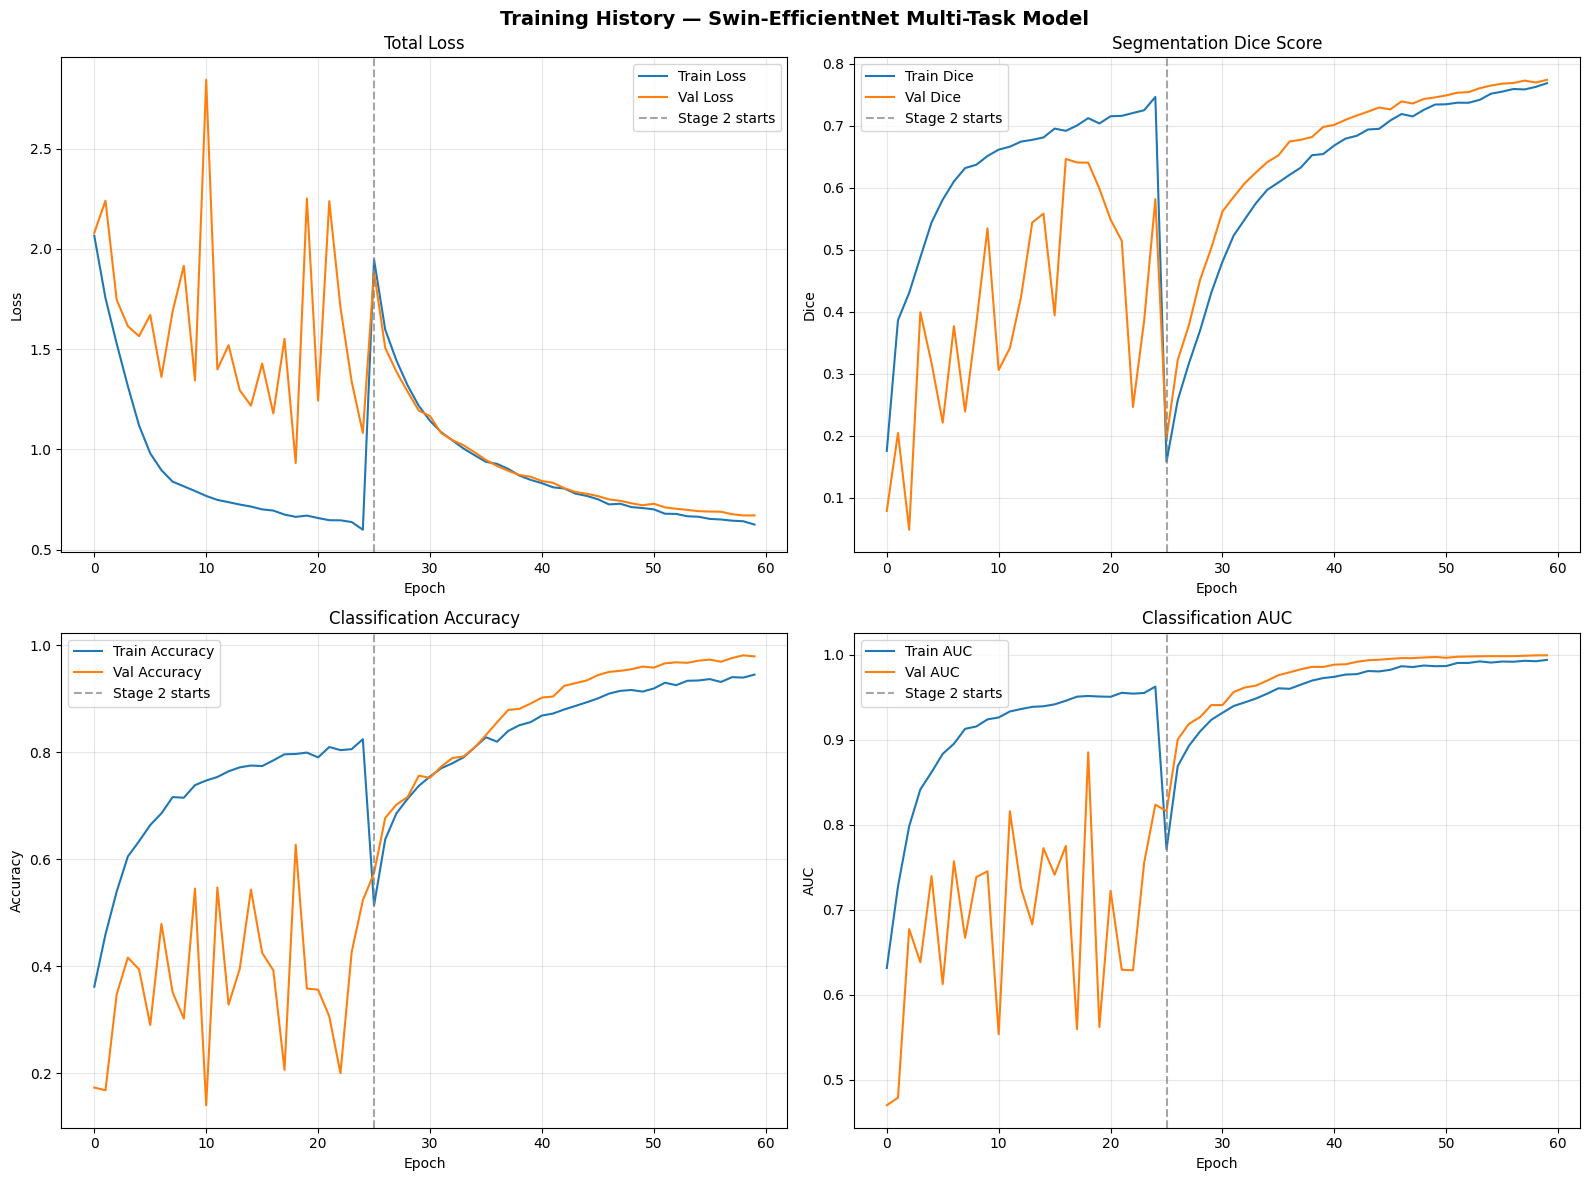

✅ Training curves saved to /kaggle/working/outputs/plots/training_curves.png


In [23]:
# CELL 6: Plot and save training history curves                                                                                  22
#
# WHY plot both stages together:
# You want to see the full training story — Stage 1 shows rapid
# initial learning, Stage 2 shows fine-tuning refinement.
# A good training curve shows loss decreasing and dice increasing
# without the validation line diverging from training (overfitting).

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV logs
h1 = pd.read_csv(f"{LOG_DIR}/stage1_history.csv")
h2 = pd.read_csv(f"{LOG_DIR}/stage2_history.csv")

# Offset Stage 2 epoch numbers
h2["epoch"] = h2["epoch"] + len(h1)

# Combine
history = pd.concat([h1, h2], ignore_index=True)
stage_boundary = len(h1)  # vertical line showing where Stage 2 started

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Training History — Swin-EfficientNet Multi-Task Model", 
             fontsize=14, fontweight="bold")

def add_stage_line(ax, boundary):
    ax.axvline(x=boundary, color="gray", linestyle="--", 
               alpha=0.7, label="Stage 2 starts")

# ── Total Loss ───────────────────────────────────────────
axes[0,0].plot(history["loss"],     label="Train Loss")
axes[0,0].plot(history["val_loss"], label="Val Loss")
add_stage_line(axes[0,0], stage_boundary)
axes[0,0].set_title("Total Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ── Dice Score ───────────────────────────────────────────
axes[0,1].plot(history["seg_output_dice"],     label="Train Dice")
axes[0,1].plot(history["val_seg_output_dice"], label="Val Dice")
add_stage_line(axes[0,1], stage_boundary)
axes[0,1].set_title("Segmentation Dice Score")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Dice")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# ── Classification Accuracy ──────────────────────────────
axes[1,0].plot(history["cls_output_accuracy"],     label="Train Accuracy")
axes[1,0].plot(history["val_cls_output_accuracy"], label="Val Accuracy")
add_stage_line(axes[1,0], stage_boundary)
axes[1,0].set_title("Classification Accuracy")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Accuracy")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── AUC ─────────────────────────────────────────────────
axes[1,1].plot(history["cls_output_auc"],     label="Train AUC")
axes[1,1].plot(history["val_cls_output_auc"], label="Val AUC")
add_stage_line(axes[1,1], stage_boundary)
axes[1,1].set_title("Classification AUC")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("AUC")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Training curves saved to {PLOT_DIR}/training_curves.png")